Converte as imagens para o formato .jpg padrão

🚀 Iniciando conversão para (224, 224) em formato .jpg...
✅ Sucesso! 120 imagens foram padronizadas na pasta 'limpo'.


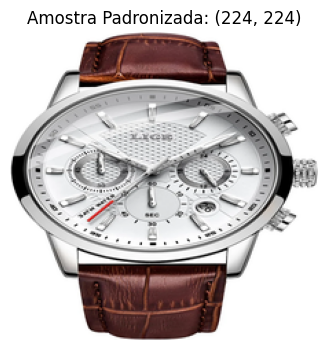

In [1]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# 1. Configurações de Caminhos
pasta_origem = 'bruto' # Nome da pasta onde estão suas subpastas (bola, cadeira, etc)
pasta_destino = 'limpo'
tamanho_padrao = (224, 224)

# Criar pasta de destino se não existir
if not os.path.exists(pasta_destino):
    os.makedirs(pasta_destino)

print(f"🚀 Iniciando conversão para {tamanho_padrao} em formato .jpg...")

# 2. Processamento
count = 0
for subdir, dirs, files in os.walk(pasta_origem):
    for file in files:
        if file.lower().endswith(('.png', '.webp', '.jpeg', '.jpg', '.bmp')):
            try:
                # Abrir e converter para RGB
                caminho_completo = os.path.join(subdir, file)
                img = Image.open(caminho_completo).convert('RGB')
                
                # Redimensionar
                img = img.resize(tamanho_padrao, Image.Resampling.LANCZOS)
                
                # Criar subpastas no destino (ex: dataset_limpo/bola/)
                pasta_classe = os.path.relpath(subdir, pasta_origem)
                caminho_salvar = os.path.join(pasta_destino, pasta_classe)
                if not os.path.exists(caminho_salvar):
                    os.makedirs(caminho_salvar)
                
                # Salvar como .jpg
                nome_arquivo = os.path.splitext(file)[0] + ".jpg"
                img.save(os.path.join(caminho_salvar, nome_arquivo), "JPEG", quality=90)
                count += 1
            except Exception as e:
                print(f"❌ Erro em {file}: {e}")

print(f"✅ Sucesso! {count} imagens foram padronizadas na pasta '{pasta_destino}'.")

# 3. Visualização de Teste (Exibe a última imagem processada)
plt.figure(figsize=(4,4))
plt.imshow(img)
plt.title(f"Amostra Padronizada: {img.size}")
plt.axis('off')
plt.show()

Inicia o treinamento

In [2]:
import numpy as np
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.preprocessing import image
from sklearn.neighbors import NearestNeighbors

# 1. Carregar Modelo Pré-treinado (ResNet50)
# Usamos pooling='avg' para que a saída seja um vetor plano (1D)
model = ResNet50(weights='imagenet', include_top=False, pooling='avg')

def extrair_vetor(img_path):
    # Carrega a imagem e prepara para o modelo
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_expand = np.expand_dims(img_array, axis=0)
    img_preprocessed = preprocess_input(img_expand)
    
    # Extrai o vetor de características (embedding)
    vetor = model.predict(img_preprocessed)
    return vetor.flatten()

# 2. Gerar vetores para todo o seu dataset limpo
vetores_lista = []
caminhos_imagens = []

for root, dirs, files in os.walk('limpo'):
    for file in files:
        if file.endswith('.jpg'):
            caminho = os.path.join(root, file)
            vetores_lista.append(extrair_vetor(caminho))
            caminhos_imagens.append(caminho)

vetores_matriz = np.array(vetores_lista)
print(f"Matriz de características gerada: {vetores_matriz.shape}")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 918ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/ste

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


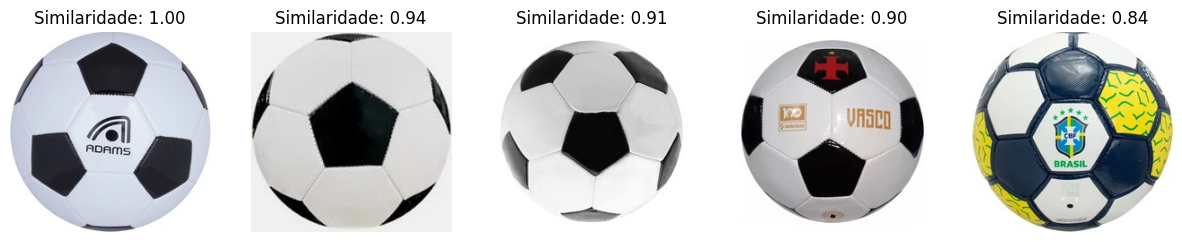

In [3]:
# 3. Treinar o buscador de vizinhos mais próximos
vizinhos = NearestNeighbors(n_neighbors=5, algorithm='brute', metric='cosine')
vizinhos.fit(vetores_matriz)

def recomendar(caminho_da_imagem_alvo):
    # Extrai o vetor da imagem que o usuário clicou
    vetor_alvo = extrair_vetor(caminho_da_imagem_alvo).reshape(1, -1)
    
    # Busca as 5 imagens mais parecidas (a primeira será ela mesma)
    distancias, indices = vizinhos.kneighbors(vetor_alvo)
    
    # Mostrar resultados
    plt.figure(figsize=(15, 5))
    for i, idx in enumerate(indices[0]):
        plt.subplot(1, 5, i+1)
        img = Image.open(caminhos_imagens[idx])
        plt.imshow(img)
        plt.title(f"Similaridade: {1 - distancias[0][i]:.2f}")
        plt.axis('off')
    plt.show()

# Teste o sistema! Escolha uma imagem qualquer do seu dataset:
recomendar(caminhos_imagens[0])

Salva um possivel modelo para reutilização em APIs

In [23]:
import pickle
import numpy as np

# Dados para salvar
dados_recomendacao = {
    "vetores": vetores_matriz,
    "caminhos": caminhos_imagens
}

# Salvando em um arquivo binário (.pkl)
with open('modelo_recomendacao.pkl', 'wb') as f:
    pickle.dump(dados_recomendacao, f)

print("✅ Vetores e caminhos salvos com sucesso em 'modelo_recomendacao.pkl'!")

✅ Vetores e caminhos salvos com sucesso em 'modelo_recomendacao.pkl'!


Realizar uma busca com um produto fora do treinamento

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


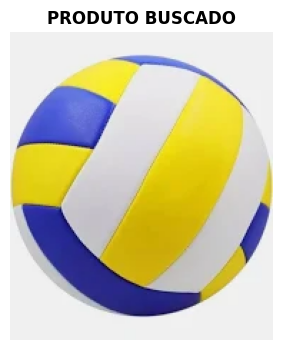


PRODUTOS RELACIONADOS:



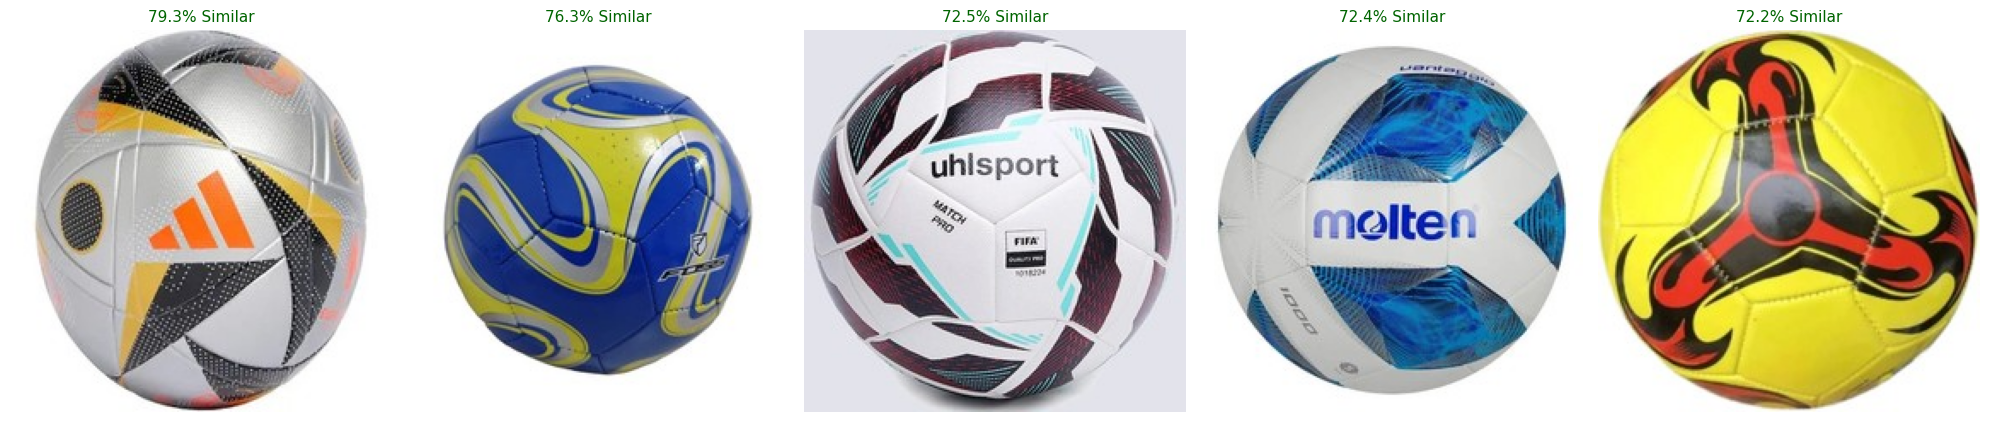

In [22]:
import matplotlib.pyplot as plt

def testar_recomendacao_externa(caminho_img):
    # 1. Extração do vetor da nova imagem
    vetor_novo = extrair_vetor(caminho_img).reshape(1, -1)
    
    # 2. Busca no sistema
    distancias, indices = vizinhos.kneighbors(vetor_novo)
    
    # --- GRÁFICO 1: A BUSCA ---
    plt.figure(figsize=(4, 4))
    img_busca = Image.open(caminho_img)
    plt.imshow(img_busca)
    plt.title("PRODUTO BUSCADO", fontsize=12, fontweight='bold')
    plt.axis('off')
    plt.show() # Força a exibição deste gráfico antes de criar o próximo

    # --- GRÁFICO 2: AS RECOMENDAÇÕES ---
    print("\n" + "="*30)
    print("PRODUTOS RELACIONADOS:")
    print("="*30 + "\n")
    
    # Criamos uma linha com 5 colunas
    fig, axes = plt.subplots(1, 5, figsize=(20, 5))
    
    for i, idx in enumerate(indices[0]):
        img_rec = Image.open(caminhos_imagens[idx])
        axes[i].imshow(img_rec)
        
        # Similaridade em %
        sim = (1 - distancias[0][i]) * 100
        axes[i].set_title(f"{sim:.1f}% Similar", fontsize=11, color='darkgreen')
        axes[i].axis('off')
        
    plt.tight_layout()
    plt.show()

# Executar o teste
testar_recomendacao_externa('teste2.jpg')